In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import matplotlib.pyplot as plt

df = (
    pl.read_parquet("../parquets/D_binance_btcusdt_orderbook_incremental.parquet")
    .unique()
    .sort("seq_id")
)


In [4]:
df.null_count()

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_prices,bid_qtys,ask_prices,ask_qtys,snapshot
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,17994,0,0,0,0,0,0,0


In [23]:
df.select(((pl.col("bid_prices").list.len() != pl.col("bid_qtys").list.len()) | (pl.col("ask_prices").list.len() != pl.col("ask_qtys").list.len())).sum().alias("length_mismatch_rows"))

length_mismatch_rows
u32
0


In [62]:
df.group_by("snapshot").len()

snapshot,len
bool,u32
false,17994


In [63]:
df.select(pl.col(["bid_prices", "bid_qtys", "ask_prices", "ask_qtys"]).list.len().eq(0).sum())

bid_prices,bid_qtys,ask_prices,ask_qtys
u32,u32,u32,u32
14,14,1437,1437


In [64]:
df = df.with_columns(
    empty_bid_update=pl.col("bid_prices").list.len() == 0,
    empty_ask_update=pl.col("ask_prices").list.len() == 0,
)
df.select(
    pl.col("empty_bid_update").sum(),
    pl.col("empty_ask_update").sum(),
)

empty_bid_update,empty_ask_update
u32,u32
14,1437


In [65]:
df.select(
    pl.col("bid_prices").list.eval(pl.element() <= 0).list.sum().sum().alias("bad_bid_price_count"),
    pl.col("ask_prices").list.eval(pl.element() <= 0).list.sum().sum().alias("bad_ask_price_count"),
    pl.col("bid_qtys").list.eval(pl.element() < 0).list.sum().sum().alias("negative_bid_qty_count"),
    pl.col("ask_qtys").list.eval(pl.element() < 0).list.sum().sum().alias("negative_ask_qty_count"),
)

bad_bid_price_count,bad_ask_price_count,negative_bid_qty_count,negative_ask_qty_count
u32,u32,u32,u32
0,0,0,0


In [66]:
df.sort("seq_id").select(
    pl.col("publish_ts").is_sorted().alias("publish_ts_monotonic_by_seq_id")
)

publish_ts_monotonic_by_seq_id
bool
true


In [67]:
bad_update_seq = []

for row in df.iter_rows(named=True):
    bid_px = [p for p, q in zip(row["bid_prices"], row["bid_qtys"]) if q > 0]
    ask_px = [p for p, q in zip(row["ask_prices"], row["ask_qtys"]) if q > 0]

    if bid_px and ask_px and max(bid_px) > min(ask_px):
        bad_update_seq.append(row["seq_id"])
len(bad_update_seq)

1

In [68]:
bad_update_seq

[98502143047]

In [69]:
df.with_columns(
    bid_len=pl.col("bid_prices").list.len(),
    ask_len=pl.col("ask_prices").list.len(),
    total_len=pl.col("bid_prices").list.len() + pl.col("ask_prices").list.len(),
).sort("total_len", descending=True).select(
    "seq_id", "publish_ts", "snapshot", "bid_len", "ask_len", "total_len"
).head(10)

seq_id,publish_ts,snapshot,bid_len,ask_len,total_len
i64,"datetime[μs, UTC]",bool,u32,u32,u32
98502447046,2026-08-13 14:21:15.724458 UTC,false,593,614,1207
98502175693,2026-08-13 14:15:47.614474 UTC,false,411,438,849
98502480837,2026-08-13 14:21:49.316119 UTC,false,378,468,846
98502043221,2026-08-13 14:12:43.814466 UTC,false,390,440,830
98502254782,2026-08-13 14:16:52.514455 UTC,false,364,359,723
98502225217,2026-08-13 14:16:27.214484 UTC,false,378,342,720
98502047262,2026-08-13 14:12:46.814341 UTC,false,329,333,662
98502332067,2026-08-13 14:18:35.914721 UTC,false,330,328,658
98502377533,2026-08-13 14:19:53.914364 UTC,false,355,302,657


In [70]:
df.select(
    (pl.col("bid_prices").list.len() + pl.col("ask_prices").list.len()).quantile(0.99).alias("p99_total_len")
)

p99_total_len
f64
307.0


In [71]:
df = df.with_columns(
    depth=pl.col("bid_prices").list.len() + pl.col("ask_prices").list.len()
)

p99_depth = df.select(pl.col("depth").quantile(0.99)).item()

df = df.with_columns(
    snapshot_like=pl.col("depth") >= p99_depth
)

In [72]:
df.select(
    pl.col("snapshot").sum().alias("snapshot_true"),
    pl.col("snapshot_like").sum().alias("snapshot_like_p99"),
    pl.col("depth").max().alias("max_depth"),
)

snapshot_true,snapshot_like_p99,max_depth
u32,u32,u32
0,183,1207


In [73]:
book_bids, book_asks, states = {}, {}, []

for row in df.iter_rows(named=True):
    if row["snapshot"] or row["snapshot_like"]:
        book_bids, book_asks = {}, {}

    for p, q in zip(row["bid_prices"], row["bid_qtys"]):
        book_bids.pop(p, None) if q == 0 else book_bids.update({p: q})

    for p, q in zip(row["ask_prices"], row["ask_qtys"]):
        book_asks.pop(p, None) if q == 0 else book_asks.update({p: q})

    states.append({
        "seq_id": row["seq_id"],
        "publish_ts": row["publish_ts"],
        "best_bid": max(book_bids) if book_bids else None,
        "best_ask": min(book_asks) if book_asks else None,
    })

book = pl.DataFrame(states).with_columns(
    crossed_book=pl.col("best_bid") > pl.col("best_ask"),
    spread=pl.col("best_ask") - pl.col("best_bid"),
)
book.select(
    pl.len().alias("rows"),
    pl.col("crossed_book").sum().alias("crossed_books"),
    pl.col("spread").min().alias("min_spread"),
    pl.col("spread").max().alias("max_spread"),
)

rows,crossed_books,min_spread,max_spread
u32,u32,f64,f64
17994,214,-325.48,0.96


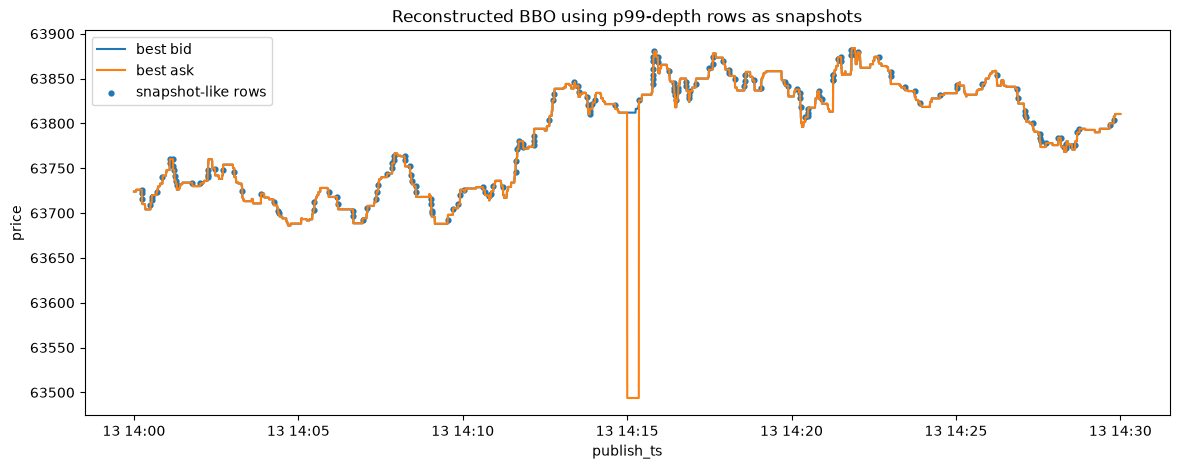

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(book["publish_ts"], book["best_bid"], label="best bid")
plt.plot(book["publish_ts"], book["best_ask"], label="best ask")
plt.scatter(
    df.filter(pl.col("snapshot_like"))["publish_ts"],
    df.filter(pl.col("snapshot_like"))["bid_prices"].list.max(),
    s=12,
    label="snapshot-like rows",
)
plt.title("Reconstructed BBO using p99-depth rows as snapshots")
plt.xlabel("publish_ts")
plt.ylabel("price")
plt.legend()
plt.show()

In [75]:
book.filter(pl.col("crossed_book") & (pl.col("seq_id") == 98502143047))

seq_id,publish_ts,best_bid,best_ask,crossed_book,spread
i64,"datetime[μs, UTC]",f64,f64,bool,f64
98502143047,2026-08-13 14:15:00.014598 UTC,63812.0,63493.72,true,-318.28


In [76]:
book.filter(pl.col("crossed_book")).sort("seq_id").head(1)

seq_id,publish_ts,best_bid,best_ask,crossed_book,spread
i64,"datetime[μs, UTC]",f64,f64,bool,f64
98502143047,2026-08-13 14:15:00.014598 UTC,63812.0,63493.72,true,-318.28


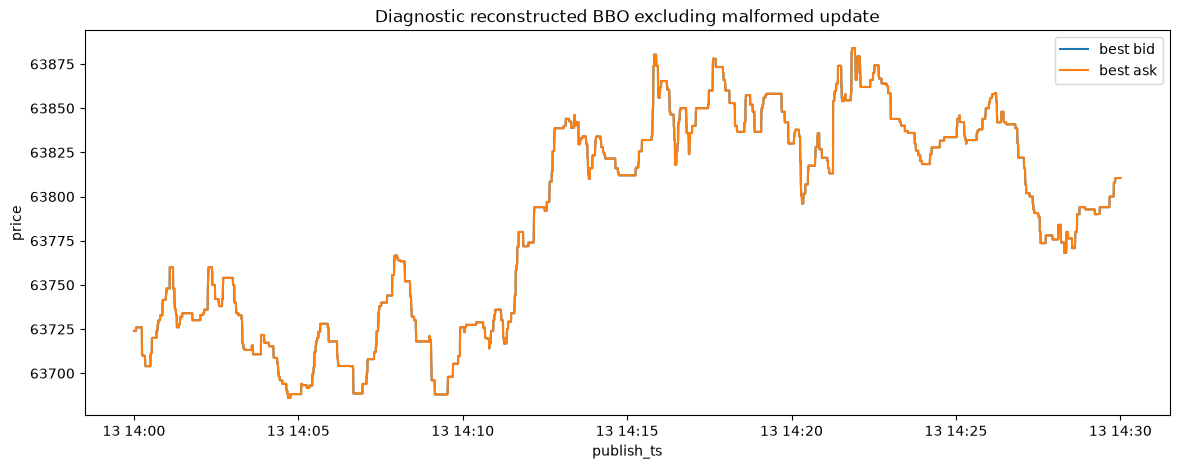

In [77]:
bad_update_seq = [98502143047]

book_bids, book_asks, states = {}, {}, []

for row in df.iter_rows(named=True):
    if row["snapshot_like"]:
        book_bids, book_asks = {}, {}

    if row["seq_id"] in bad_update_seq:
        continue

    for p, q in zip(row["bid_prices"], row["bid_qtys"]):
        book_bids.pop(p, None) if q == 0 else book_bids.update({p: q})

    for p, q in zip(row["ask_prices"], row["ask_qtys"]):
        book_asks.pop(p, None) if q == 0 else book_asks.update({p: q})

    states.append({
        "seq_id": row["seq_id"],
        "publish_ts": row["publish_ts"],
        "best_bid": max(book_bids) if book_bids else None,
        "best_ask": min(book_asks) if book_asks else None,
    })

book_clean = pl.DataFrame(states).with_columns(
    spread=pl.col("best_ask") - pl.col("best_bid"),
    crossed_book=pl.col("best_bid") > pl.col("best_ask"),
)
plt.figure(figsize=(14, 5))
plt.plot(book_clean["publish_ts"], book_clean["best_bid"], label="best bid")
plt.plot(book_clean["publish_ts"], book_clean["best_ask"], label="best ask")
plt.title("Diagnostic reconstructed BBO excluding malformed update")
plt.xlabel("publish_ts")
plt.ylabel("price")
plt.legend()
plt.show()

In [78]:
book_clean.select(pl.col("crossed_book").sum().alias("crossed_book_count"))

crossed_book_count
u32
0


In [79]:
book_clean.select(pl.len().alias("rows"), pl.col("crossed_book").sum().alias("crossed_books"), pl.lit(len(book_bids) + len(book_asks)).alias("final_price_levels"))

rows,crossed_books,final_price_levels
u32,u32,i32
17993,0,537
